In [ ]:
# Settings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras

np.random.seed(42)
tf.random.set_seed(42)
keras.utils.set_random_seed(42)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

# Set all text weights and sizes to 14 Bold globally
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'

# Ensure individual components inherit the bold styling and size
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.titleweight'] = 'bold'

# Apply bold to axis tick numbers
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# Dataset loading

In [ ]:
import keras.datasets

(x_train, Y_train), (x_test, Y_test) = keras.datasets.mnist.load_data()

X_train = x_train[:10000]
y_train = Y_train[:10000]

X_test = x_test[:2000]
y_test = Y_test[:2000]

# Normalize pixel values
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Train images min/max:", X_train.min(), X_train.max())
print("Test images min/max: ", X_test.min(), X_test.max())

print("Train images shape:", X_train.shape)
print("Train labels shape:", y_train.shape)
print("Test images shape: ", X_test.shape)
print("Test labels shape: ", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train images min/max: 0.0 1.0
Test images min/max:  0.0 1.0
Train images shape: (10000, 28, 28)
Train labels shape: (10000,)
Test images shape:  (2000, 28, 28)
Test labels shape:  (2000,)


# Fully Connected Autoencoder

In [ ]:
from keras import layers, optimizers, Model

X_train_flat = X_train.reshape((X_train.shape[0], -1))
X_test_flat = X_test.reshape((X_test.shape[0], -1))

# 2. Build the Autoencoder Architecture
input_img = layers.Input(shape=(784,))

# Encoder
encoded = layers.Dense(128, activation="relu")(input_img)
encoded = layers.Dense(32, activation="relu")(encoded)
latent = layers.Dense(16, activation="relu", name="latent_space")(encoded)

# Decoder
decoded = layers.Dense(32, activation="relu")(latent)
decoded = layers.Dense(128, activation="relu")(decoded)
decoded_output = layers.Dense(784, activation="sigmoid")(decoded)

# Autoencoder Model
autoencoder = Model(inputs=input_img, outputs=decoded_output)

# 3. Compile Model
autoencoder.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)

# 4. Train Autoencoder
history = autoencoder.fit(
    X_train_flat,
    X_train_flat,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test_flat, X_test_flat)
)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - loss: 0.3442 - val_loss: 0.2423
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2255 - val_loss: 0.2035
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1899 - val_loss: 0.1783
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1715 - val_loss: 0.1650
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1593 - val_loss: 0.1555
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1512 - val_loss: 0.1494
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1454 - val_loss: 0.1447
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1413 - val_loss: 0.1414
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1381 - val_loss: 0.1390
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1357 - val_loss: 0.1370
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1336 - val_loss: 0.1356
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1316 - val

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


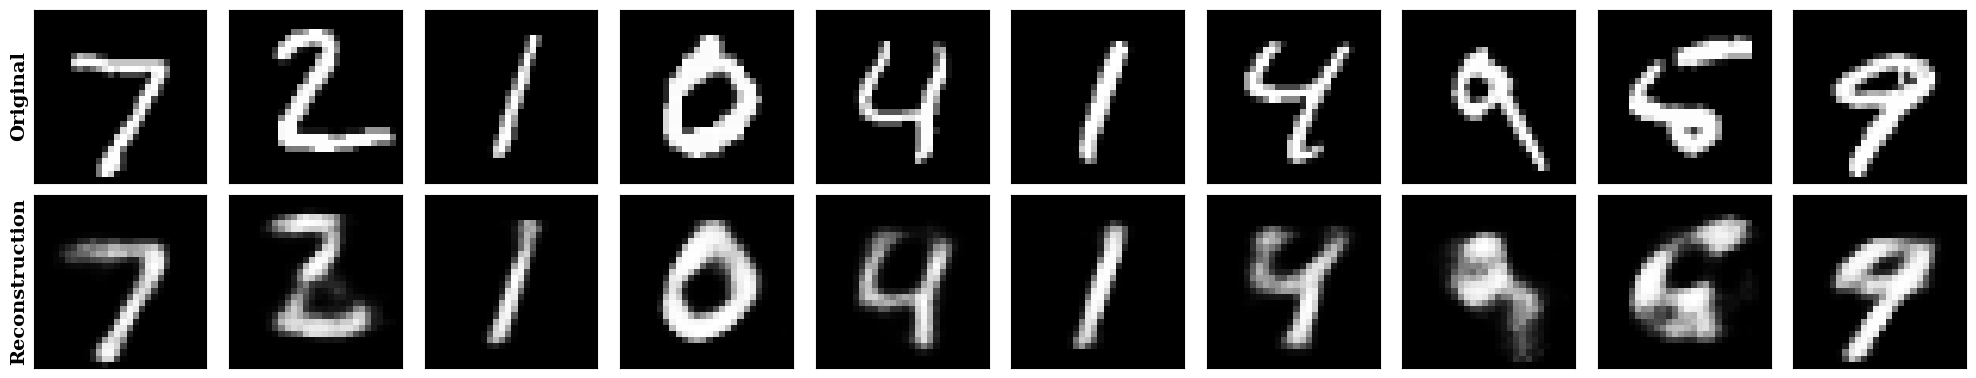

In [ ]:
# 1. Predict reconstructions on the test set
decoded_imgs = autoencoder.predict(X_test_flat)

# 2. Set up grid: 10 test images (Original on top, Reconstruction below)
n_images = 10
fig, axes = plt.subplots(2, n_images, figsize=(20, 4))

for i in range(n_images):
    # Display Original
    ax_orig = axes[0, i]
    ax_orig.imshow(X_test_flat[i].reshape(28, 28), cmap="gray")
    if i == 0:
        ax_orig.set_ylabel("Original", fontsize=14, fontweight="bold")
    ax_orig.set_xticks([])
    ax_orig.set_yticks([])

    # Display Reconstruction
    ax_recon = axes[1, i]
    ax_recon.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    if i == 0:
        ax_recon.set_ylabel("Reconstruction", fontsize=14, fontweight="bold")
    ax_recon.set_xticks([])
    ax_recon.set_yticks([])

plt.tight_layout()

# 3. Save plot to disk as PNG and EPS at 600 DPI
plt.savefig("original_vs_reconstructed.png", dpi=600, bbox_inches="tight")
plt.savefig("original_vs_reconstructed.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

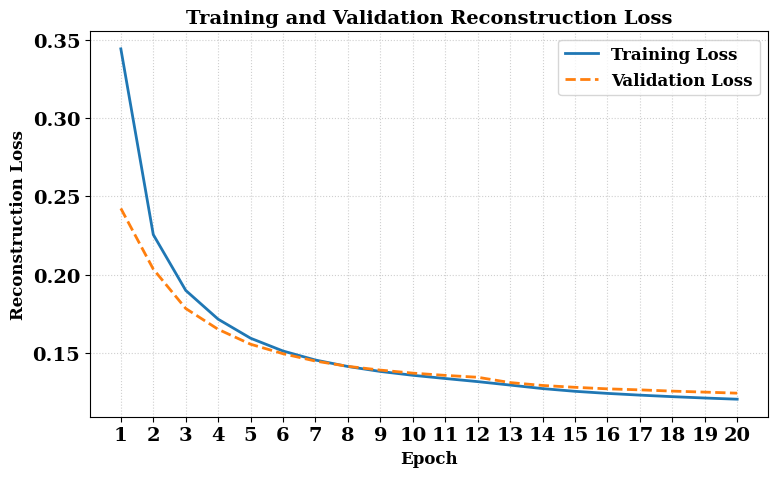

In [ ]:
# 1. Extract loss values and epochs from the training history
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(train_loss) + 1)

# 2. Create the loss curve plot
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Training Loss", color="#1f77b4", linewidth=2)
plt.plot(epochs, val_loss, label="Validation Loss", color="#ff7f0e", linewidth=2, linestyle="--")

# 3. Configure labels, title, and styling
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Reconstruction Loss", fontsize=12)
plt.title("Training and Validation Reconstruction Loss", fontsize=14, fontweight="bold")
plt.xticks(epochs)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=12)

plt.tight_layout()

# 4. Save plot to disk as PNG and EPS at 600 DPI
plt.savefig("reconstruction_loss_curve.png", dpi=600, bbox_inches="tight")
plt.savefig("reconstruction_loss_curve.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

In [ ]:
from skimage.metrics import structural_similarity as ssim

# 1. Generate reconstructions for the entire test set
decoded_test = autoencoder.predict(X_test_flat)

# 2. Reshape to original 2D image dimensions (2000, 28, 28)
orig_images = X_test_flat.reshape((-1, 28, 28))
recon_images = decoded_test.reshape((-1, 28, 28))

# 3. Calculate Mean Squared Error (MSE) and Mean Absolute Error (MAE)
mse_val = np.mean((orig_images - recon_images) ** 2)
mae_val = np.mean(np.abs(orig_images - recon_images))

# 4. Calculate Structural Similarity Index (SSIM) and SSIM Loss (1 - SSIM)
# data_range=1.0 is specified since the pixel values are normalized to [0, 1]
ssim_scores = [
    ssim(orig_images[i], recon_images[i], data_range=1.0)
    for i in range(len(orig_images))
]
mean_ssim = np.mean(ssim_scores)
ssim_loss = 1.0 - mean_ssim

# 5. Display the metrics
print("--- Reconstruction Quality on Test Set ---")
print(f"MSE Loss:       {mse_val:.6f}")
print(f"MAE Loss:       {mae_val:.6f}")
print(f"Mean SSIM:      {mean_ssim:.6f}")
print(f"SSIM Loss (1-S): {ssim_loss:.6f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
--- Reconstruction Quality on Test Set ---
MSE Loss:       0.020998
MAE Loss:       0.055382
Mean SSIM:      0.751880
SSIM Loss (1-S): 0.248120


In [ ]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 633,122 (2.42 MB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 422,082 (1.61 MB)

# Convolutional Autoencoder

In [ ]:
# 1. Ensure images have the channel dimension (28, 28, 1)
X_train_conv = np.expand_dims(X_train, axis=-1)
X_test_conv = np.expand_dims(X_test, axis=-1)

# 2. Build the Convolutional Autoencoder Architecture
input_img = layers.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(32, 3, activation="relu", padding="same")(input_img)
x = layers.MaxPooling2D(2, padding="same")(x)
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
encoded = layers.MaxPooling2D(2, padding="same")(x)

# Decoder
x = layers.Conv2D(64, 3, activation="relu", padding="same")(encoded)
x = layers.UpSampling2D(2)(x)
x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
x = layers.UpSampling2D(2)(x)
decoded_output = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

# Construct Model
conv_autoencoder = keras.Model(inputs=input_img, outputs=decoded_output, name="conv_autoencoder")

# 3. Compile Model with the same hyperparameters
conv_autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)

# 4. Print Model Summary
conv_autoencoder.summary()

# 5. Train Model
conv_history = conv_autoencoder.fit(
    X_train_conv,
    X_train_conv,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test_conv, X_test_conv)
)

Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - loss: 0.2463 - val_loss: 0.1027
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0925 - val_loss: 0.0840
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0830 - val_loss: 0.0785
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0788 - val_loss: 0.0754
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0761 - val_loss: 0.0741
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0746 - val_loss: 0.0727
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0734 - val_loss: 0.0714
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0727 - val_loss: 0.0708
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0718 - val_loss: 0.0703
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0713 - val_loss: 0.0696
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0708 - val_loss: 0.0691
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0703 - val_l

In [ ]:
# 1. Predict reconstructions on the test set using the Conv Autoencoder
conv_decoded_imgs = conv_autoencoder.predict(X_test_conv)

# 2. Squeeze channel dimension to get 2D images: (2000, 28, 28)
orig_test_imgs = np.squeeze(X_test_conv, axis=-1)
recon_test_imgs = np.squeeze(conv_decoded_imgs, axis=-1)

# 3. Compute Mean Squared Error (MSE) and Mean Absolute Error (MAE)
mse_val_conv = np.mean((orig_test_imgs - recon_test_imgs) ** 2)
mae_val_conv = np.mean(np.abs(orig_test_imgs - recon_test_imgs))

# 4. Compute Structural Similarity Index (SSIM) across test samples
ssim_scores_conv = [
    ssim(orig, recon, data_range=1.0)
    for orig, recon in zip(orig_test_imgs, recon_test_imgs)
]
mean_ssim_conv = np.mean(ssim_scores_conv)

# SSIM loss is defined as 1 - SSIM
ssim_loss_conv = 1.0 - mean_ssim_conv

# 5. Display results
print("Convolutional Autoencoder Test Set Metrics (2000 images):")
print(f"  MSE:       {mse_val_conv:.6f}")
print(f"  MAE:       {mae_val_conv:.6f}")
print(f"  SSIM:      {mean_ssim_conv:.6f}")
print(f"  SSIM Loss: {ssim_loss_conv:.6f}  (defined as 1 - SSIM)")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Convolutional Autoencoder Test Set Metrics (2000 images):
  MSE:       0.002506
  MAE:       0.014868
  SSIM:      0.974898
  SSIM Loss: 0.025102  (defined as 1 - SSIM)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


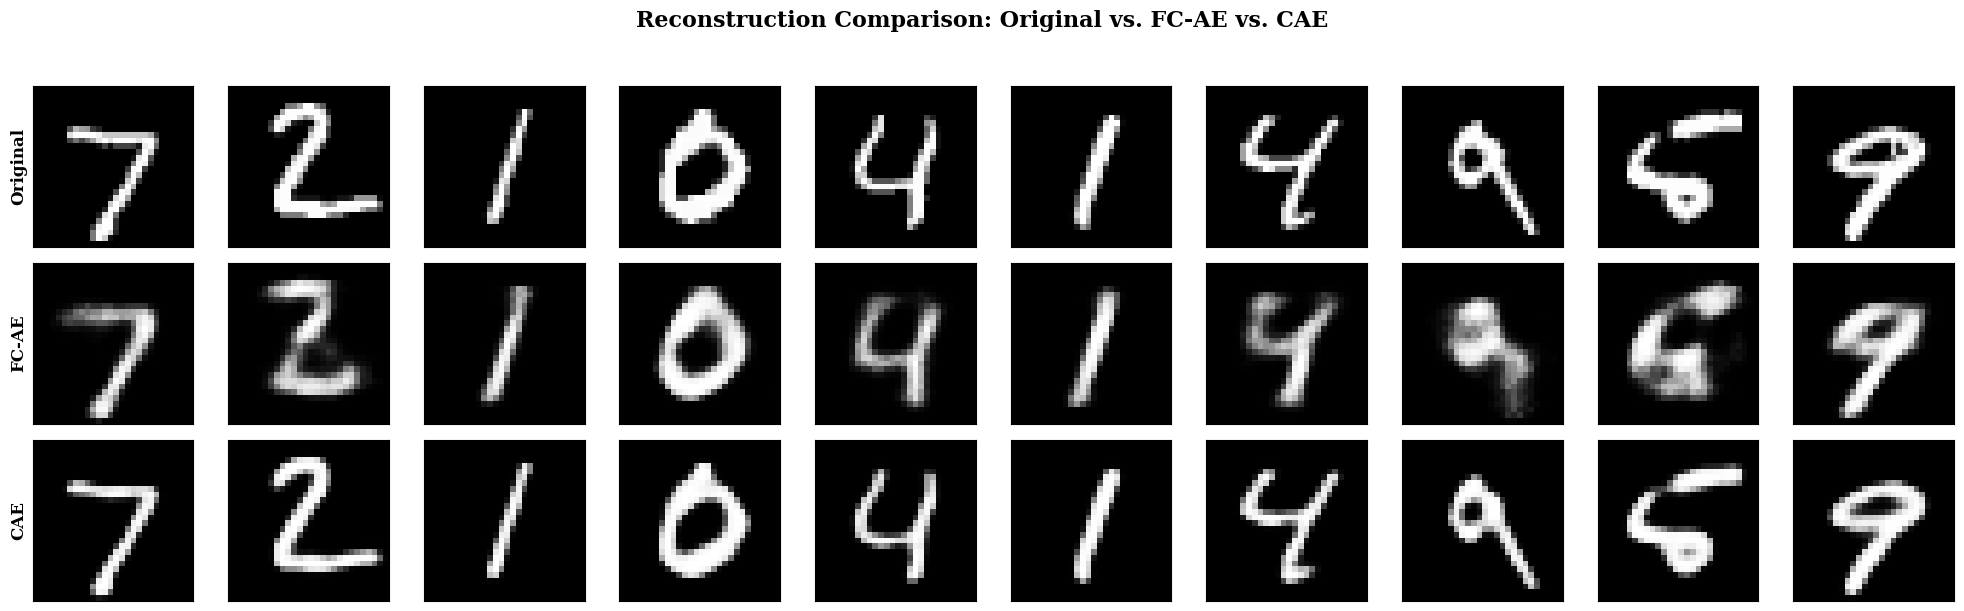

In [ ]:
# 1. Generate predictions from both models on the test set
fc_decoded_imgs = autoencoder.predict(X_test_flat)
conv_decoded_imgs = conv_autoencoder.predict(X_test_conv)

# 2. Set up grid: 10 test images, 3 rows (Original, FC-AE, CAE)
n_images = 10
fig, axes = plt.subplots(3, n_images, figsize=(20, 6))

for i in range(n_images):
    # Row 1: Original Image
    ax_orig = axes[0, i]
    ax_orig.imshow(X_test_flat[i].reshape(28, 28), cmap="gray")
    if i == 0:
        ax_orig.set_ylabel("Original", fontsize=12, fontweight="bold")
    ax_orig.set_xticks([])
    ax_orig.set_yticks([])

    # Row 2: Fully Connected Autoencoder Reconstruction
    ax_fc = axes[1, i]
    ax_fc.imshow(fc_decoded_imgs[i].reshape(28, 28), cmap="gray")
    if i == 0:
        ax_fc.set_ylabel("FC-AE", fontsize=12, fontweight="bold")
    ax_fc.set_xticks([])
    ax_fc.set_yticks([])

    # Row 3: Convolutional Autoencoder Reconstruction
    ax_conv = axes[2, i]
    ax_conv.imshow(conv_decoded_imgs[i].reshape(28, 28), cmap="gray")
    if i == 0:
        ax_conv.set_ylabel("CAE", fontsize=12, fontweight="bold")
    ax_conv.set_xticks([])
    ax_conv.set_yticks([])

plt.suptitle("Reconstruction Comparison: Original vs. FC-AE vs. CAE", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()

# 3. Save plot to disk as PNG and EPS at 600 DPI
plt.savefig("reconstruction_comparison.png", dpi=600, bbox_inches="tight")
plt.savefig("reconstruction_comparison.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

# Adding Noise to Images

In [ ]:
sigma = 0.2
p = 0.10

# ---------------------------------------------------------
# 1. Add Gaussian Noise: x_noisy = x + n, n ~ N(0, sigma^2)
# ---------------------------------------------------------
# Gaussian noise for FC-AE (flat: N, 784)
noise_train_g = np.random.normal(loc=0.0, scale=sigma, size=X_train_flat.shape)
noise_test_g = np.random.normal(loc=0.0, scale=sigma, size=X_test_flat.shape)

X_train_noisy_gauss = np.clip(X_train_flat + noise_train_g, 0.0, 1.0)
X_test_noisy_gauss = np.clip(X_test_flat + noise_test_g, 0.0, 1.0)

# Gaussian noise for CAE (conv: N, 28, 28, 1)
noise_train_g_conv = np.random.normal(loc=0.0, scale=sigma, size=X_train_conv.shape)
noise_test_g_conv = np.random.normal(loc=0.0, scale=sigma, size=X_test_conv.shape)

X_train_conv_noisy_gauss = np.clip(X_train_conv + noise_train_g_conv, 0.0, 1.0)
X_test_conv_noisy_gauss = np.clip(X_test_conv + noise_test_g_conv, 0.0, 1.0)


# ---------------------------------------------------------
# 2. Add Salt-and-Pepper Noise
# ---------------------------------------------------------
def add_salt_and_pepper(images, p):
    noisy_images = images.copy()
    num_pixels = images.size

    # Salt (1.0)
    num_salt = int(np.ceil(p * num_pixels * 0.5))

    # Corrected: Use 'i' instead of 'i - 1'
    salt_coords = [np.random.randint(0, i, num_salt) for i in images.shape]
    noisy_images[tuple(salt_coords)] = 1.0

    # Pepper (0.0)
    num_pepper = int(np.ceil(p * num_pixels * 0.5))
    pepper_coords = [np.random.randint(0, i, num_pepper) for i in images.shape]
    noisy_images[tuple(pepper_coords)] = 0.0

    return noisy_images

# Salt-and-Pepper for Flat inputs
X_train_noisy_sp = add_salt_and_pepper(X_train_flat, p)
X_test_noisy_sp = add_salt_and_pepper(X_test_flat, p)

# Salt-and-Pepper for Conv inputs
X_train_conv_noisy_sp = add_salt_and_pepper(X_train_conv, p)
X_test_conv_noisy_sp = add_salt_and_pepper(X_test_conv, p)

print("Gaussian Noisy Train Range: ", X_train_noisy_gauss.min(), "to", X_train_noisy_gauss.max())
print("Salt-and-Pepper Train Range:", X_train_noisy_sp.min(), "to", X_train_noisy_sp.max())

Gaussian Noisy Train Range:  0.0 to 1.0
Salt-and-Pepper Train Range: 0.0 to 1.0


In [ ]:
# Gaussian noise
input_img_g = layers.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(32, 3, activation="relu", padding="same")(input_img_g)
x = layers.MaxPooling2D(2, padding="same")(x)
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
encoded_g = layers.MaxPooling2D(2, padding="same")(x)

# Decoder
x = layers.Conv2D(64, 3, activation="relu", padding="same")(encoded_g)
x = layers.UpSampling2D(2)(x)
x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
x = layers.UpSampling2D(2)(x)
decoded_output_g = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

cdae_gaussian = keras.Model(inputs=input_img_g, outputs=decoded_output_g, name="cdae_gaussian")

cdae_gaussian.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)

print("=" * 65)
print("Conv Denoising Autoencoder (Gaussian Noise) - Model Summary")
print("=" * 65)
cdae_gaussian.summary()

# Train CDAE on Gaussian noisy inputs -> clean 2D targets
cdae_gaussian_history = cdae_gaussian.fit(
    X_train_conv_noisy_gauss,
    X_train_conv,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test_conv_noisy_gauss, X_test_conv)
)


# Salt and pepper
input_img_sp = layers.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(32, 3, activation="relu", padding="same")(input_img_sp)
x = layers.MaxPooling2D(2, padding="same")(x)
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
encoded_sp = layers.MaxPooling2D(2, padding="same")(x)

# Decoder
x = layers.Conv2D(64, 3, activation="relu", padding="same")(encoded_sp)
x = layers.UpSampling2D(2)(x)
x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
x = layers.UpSampling2D(2)(x)
decoded_output_sp = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

cdae_sp = keras.Model(inputs=input_img_sp, outputs=decoded_output_sp, name="cdae_salt_and_pepper")

cdae_sp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)

print("\n" + "=" * 65)
print("Conv Denoising Autoencoder (Salt-and-Pepper Noise) - Model Summary")
print("=" * 65)
cdae_sp.summary()

# Train CDAE on Salt-and-Pepper noisy inputs -> clean 2D targets
cdae_sp_history = cdae_sp.fit(
    X_train_conv_noisy_sp,
    X_train_conv,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test_conv_noisy_sp, X_test_conv)
)

Conv Denoising Autoencoder (Gaussian Noise) - Model Summary


Model: "cdae_gaussian"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - loss: 0.2416 - val_loss: 0.1211
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1043 - val_loss: 0.0933
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0917 - val_loss: 0.0874
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0875 - val_loss: 0.0843
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0851 - val_loss: 0.0847
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0832 - val_loss: 0.0820
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0818 - val_loss: 0.0806
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0808 - val_loss: 0.0796
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0799 - val_loss: 0.0786
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0791 - val_loss: 0.0777
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0785 - val_loss: 0.0770
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0779 - val

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


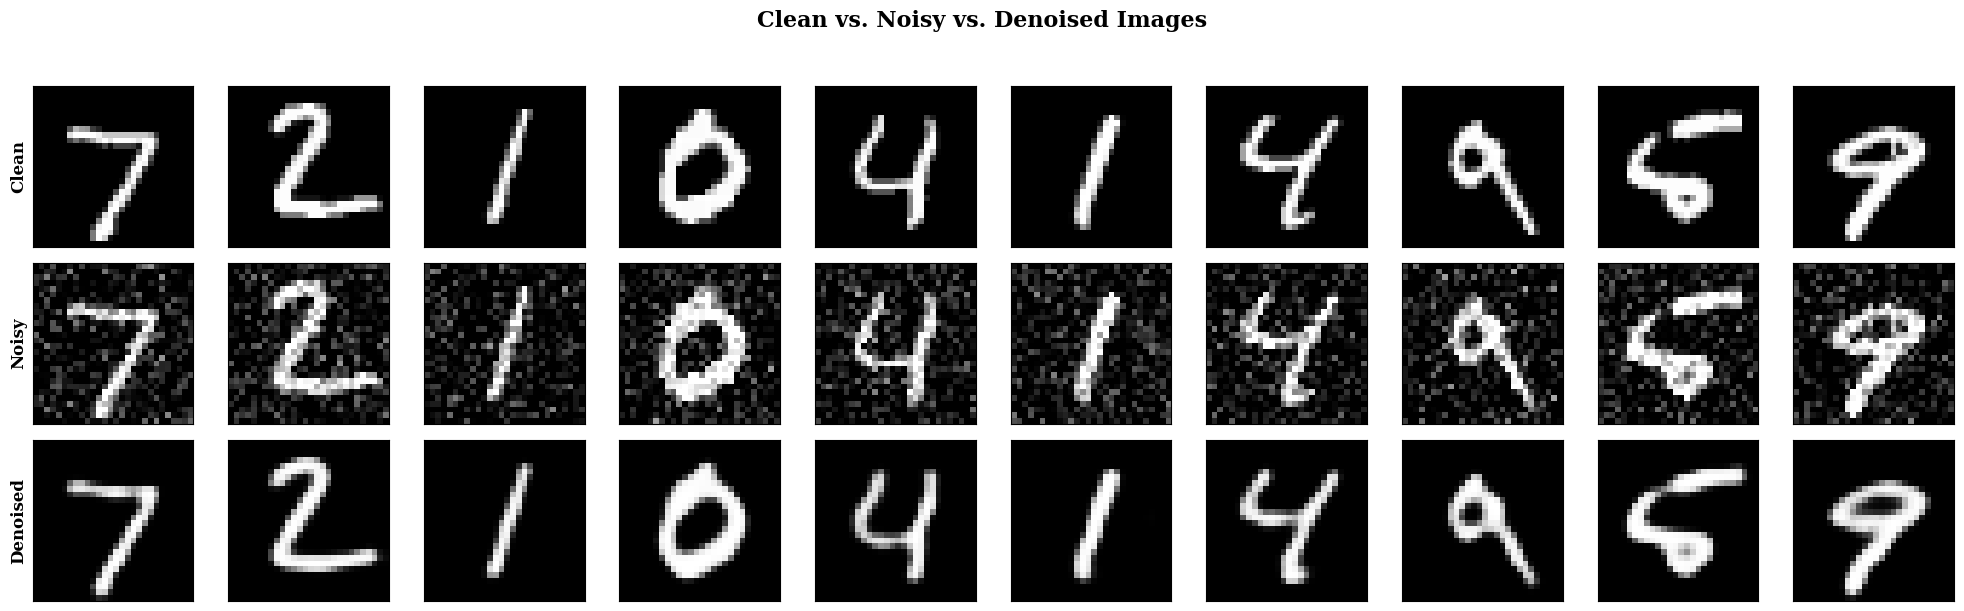

In [ ]:
denoised_imgs_g = cdae_gaussian.predict(X_test_conv_noisy_gauss)

n_images = 10
fig, axes = plt.subplots(3, n_images, figsize=(20, 6))

for i in range(n_images):
    # Row 1: Clean (Original)
    ax_clean = axes[0, i]
    ax_clean.imshow(X_test_flat[i].reshape(28, 28), cmap="gray")
    if i == 0:
        ax_clean.set_ylabel("Clean", fontsize=12, fontweight="bold")
    ax_clean.set_xticks([])
    ax_clean.set_yticks([])

    # Row 2: Noisy
    ax_noisy = axes[1, i]
    ax_noisy.imshow(X_test_conv_noisy_gauss[i].reshape(28, 28), cmap="gray")
    if i == 0:
        ax_noisy.set_ylabel("Noisy", fontsize=12, fontweight="bold")
    ax_noisy.set_xticks([])
    ax_noisy.set_yticks([])

    # Row 3: Denoised
    ax_denoised = axes[2, i]
    ax_denoised.imshow(denoised_imgs_g[i].reshape(28, 28), cmap="gray")
    if i == 0:
        ax_denoised.set_ylabel("Denoised", fontsize=12, fontweight="bold")
    ax_denoised.set_xticks([])
    ax_denoised.set_yticks([])

plt.suptitle("Clean vs. Noisy vs. Denoised Images", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()

# Save Plot 4 as PNG and EPS at 600 DPI
plt.savefig("clean_vs_noisy_vs_denoised.png", dpi=600, bbox_inches="tight")
plt.savefig("clean_vs_noisy_vs_denoised.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
noise_levels = [0.1, 0.2, 0.3]
metrics_results = []

mse_list = []
mae_list = []
ssim_list = []

for sigma_val in noise_levels:
    # 1. Generate noisy test data for current noise level
    noise_test = np.random.normal(loc=0.0, scale=sigma_val, size=X_test_conv.shape)
    X_test_noisy_curr = np.clip(X_test_conv + noise_test, 0.0, 1.0)

    # 2. Reconstruct using the trained DAE model
    reconstructed = cdae_gaussian.predict(X_test_noisy_curr)

    # 3. Reshape for SSIM and metric evaluation
    orig_imgs = X_test_flat.reshape(-1, 28, 28)
    recon_imgs = reconstructed.reshape(-1, 28, 28)

    # 4. Compute metrics
    mse_val = np.mean((orig_imgs - recon_imgs) ** 2)
    mae_val = np.mean(np.abs(orig_imgs - recon_imgs))
    ssim_val = np.mean([
        ssim(orig, recon, data_range=1.0)
        for orig, recon in zip(orig_imgs, recon_imgs)
    ])

    mse_list.append(mse_val)
    mae_list.append(mae_val)
    ssim_list.append(ssim_val)

    metrics_results.append({
        "Noise Level": sigma_val,
        "MSE": mse_val,
        "MAE": mae_val,
        "SSIM": ssim_val
    })

# Print exact values
for r in metrics_results:
    print(f"sigma = {r['Noise Level']:.1f}  MSE = {r['MSE']:.6f}  MAE = {r['MAE']:.6f}  SSIM = {r['SSIM']:.6f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
sigma = 0.1  MSE = 0.003813  MAE = 0.018184  SSIM = 0.958773
sigma = 0.2  MSE = 0.004775  MAE = 0.021443  SSIM = 0.944068
sigma = 0.3  MSE = 0.007161  MAE = 0.029384  SSIM = 0.868043


<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_635/2328201305.py:4: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_xlabel("Noise Level ($\sigma$)", fontsize=12)


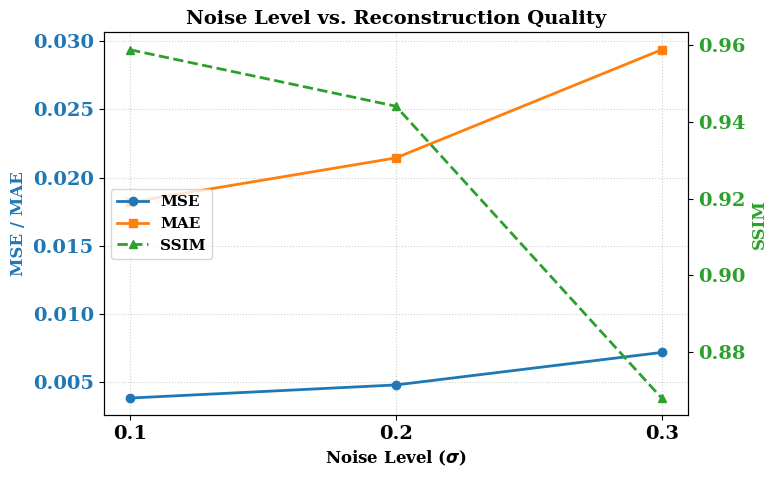

In [ ]:
fig, ax1 = plt.subplots(figsize=(8, 5))

color = "#1f77b4"
ax1.set_xlabel("Noise Level ($\sigma$)", fontsize=12)
ax1.set_ylabel("MSE / MAE", fontsize=12, color=color)
ax1.plot(noise_levels, mse_list, label="MSE", marker="o", color="#1f77b4", linewidth=2)
ax1.plot(noise_levels, mae_list, label="MAE", marker="s", color="#ff7f0e", linewidth=2)
ax1.tick_params(axis="y", labelcolor=color)
ax1.set_xticks(noise_levels)
ax1.grid(True, linestyle=":", alpha=0.6)

# Secondary y-axis for SSIM
ax2 = ax1.twinx()
color = "#2ca02c"
ax2.set_ylabel("SSIM", fontsize=12, color=color)
ax2.plot(noise_levels, ssim_list, label="SSIM", marker="^", color=color, linewidth=2, linestyle="--")
ax2.tick_params(axis="y", labelcolor=color)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center left", fontsize=11)

plt.title("Noise Level vs. Reconstruction Quality", fontsize=14, fontweight="bold")
plt.tight_layout()

# Save Plot 5 as PNG and EPS at 600 DPI
plt.savefig("noise_level_vs_reconstruction_quality.png", dpi=600, bbox_inches="tight")
plt.savefig("noise_level_vs_reconstruction_quality.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()

# Variational Autoencoder

In [ ]:
import tensorflow as tf

latent_dim = 2

# ---------------------------------------------------------
# 1. Sampling Layer (Reparameterization Trick)
# ---------------------------------------------------------
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


# ---------------------------------------------------------
# 2. Encoder Architecture
# ---------------------------------------------------------
encoder_inputs = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs) # (14, 14, 32)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)             # (7, 7, 64)
x = layers.Flatten()(x)
x = layers.Dense(64, activation="relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
print("Encoder Summary")
encoder.summary()


# ---------------------------------------------------------
# 3. Decoder Architecture
# ---------------------------------------------------------
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)  # (14, 14, 64)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)  # (28, 28, 32)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x) # (28, 28, 1)

decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
print("Decoder Summary")
decoder.summary()


# ---------------------------------------------------------
# 4. VAE Model with Custom Training Step (ELBO Loss)
# ---------------------------------------------------------
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # Reconstruction Loss (Binary Cross Entropy)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)
                )
            )

            # KL Divergence Loss
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)
            )
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1
            )
        )

        total_loss = reconstruction_loss + kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }


# ---------------------------------------------------------
# 5. Compile and Train VAE
# ---------------------------------------------------------
vae = VAE(encoder, decoder)
vae.summary()
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

vae_history = vae.fit(
    X_train_conv,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test_conv, X_test_conv)
)


Encoder Summary


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 14, 14,    │        320 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │    200,768 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        130 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        130 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 219,844 (858.77 KB)

 Trainable params: 219,844 (858.77 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Functional)            │ ((None, 2), (None, 2), │       219,844 │
│                                 │ (None, 2))             │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │        65,089 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 284,933 (1.09 MB)

 Trainable params: 284,933 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - kl_loss: 1.9902 - loss: 295.6849 - reconstruction_loss: 293.6947 - val_kl_loss: 0.1147 - val_loss: 205.3767 - val_reconstruction_loss: 205.2620
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 1.4440 - loss: 201.8867 - reconstruction_loss: 200.4428 - val_kl_loss: 2.8147 - val_loss: 182.8989 - val_reconstruction_loss: 180.0842
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 3.6097 - loss: 184.4747 - reconstruction_loss: 180.8650 - val_kl_loss: 3.8485 - val_loss: 176.0723 - val_reconstruction_loss: 172.2238
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 3.9744 - loss: 179.4202 - reconstruction_loss: 175.4458 - val_kl_loss: 4.0831 - val_loss: 172.4276 - val_reconstruction_loss: 168.3444
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 4.2276 - loss: 176.0637 - reconstruction_loss: 171.8360 - val_kl_loss: 4.2259 - val_loss: 170.0958 - val_reconstruction_loss: 165.8699
Epoch 6/20
79/79 ━

<>:24: SyntaxWarning: invalid escape sequence '\i'
<>:24: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_635/2349976490.py:24: SyntaxWarning: invalid escape sequence '\i'
  plt.title("VAE Latent Space ($z \in \mathbb{R}^2$)", fontsize=16, fontweight="bold")


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


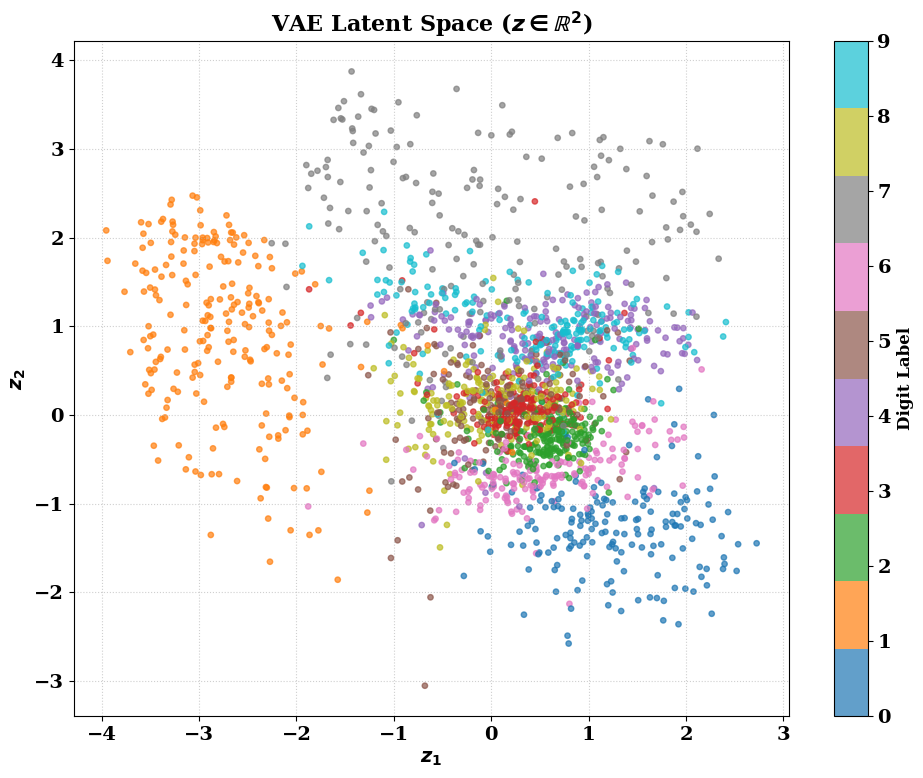

In [ ]:
# 1. Encode the test set to obtain the 2D latent means (z_mean)
z_mean, _, _ = vae.encoder.predict(X_test_conv)

# 2. Extract digit labels for the test set
labels = y_test[:2000]

# 3. Create the 2D Latent Space Scatter Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    z_mean[:, 0],
    z_mean[:, 1],
    c=labels,
    cmap="tab10",
    alpha=0.7,
    s=15
)

# 4. Add Colorbar and Labels
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_label("Digit Label", fontsize=12, fontweight="bold")

plt.xlabel("$z_1$", fontsize=14, fontweight="bold")
plt.ylabel("$z_2$", fontsize=14, fontweight="bold")
plt.title("VAE Latent Space ($z \in \mathbb{R}^2$)", fontsize=16, fontweight="bold")
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()

# 5. Save plot to disk as PNG and EPS at 600 DPI
plt.savefig("vae_latent_space.png", dpi=600, bbox_inches="tight")
plt.savefig("vae_latent_space.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_635/1199464105.py:15: SyntaxWarning: invalid escape sequence '\s'
  plt.suptitle("Randomly Generated Images ($z \sim N(0, I)$)", fontsize=16, fontweight="bold")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step


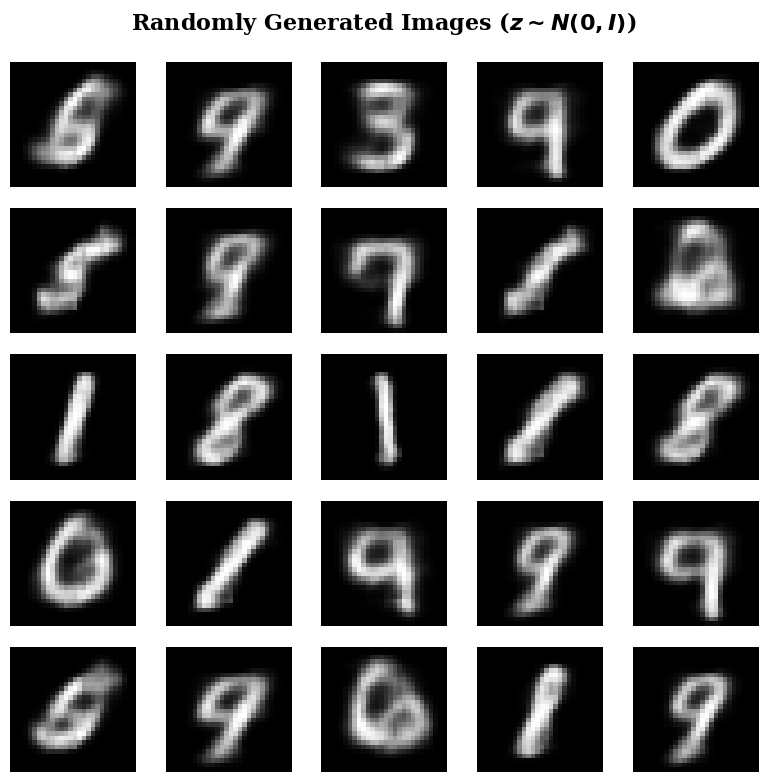

In [ ]:
# 1. Sample 25 latent vectors from standard normal distribution z ~ N(0, I)
n_samples = 25
z_samples = np.random.normal(loc=0.0, scale=1.0, size=(n_samples, latent_dim))

# 2. Pass sampled latent vectors through the decoder
generated_imgs = vae.decoder.predict(z_samples)

# 3. Create Plot 7: 5x5 Grid of Randomly Generated Images
fig, axes = plt.subplots(5, 5, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(generated_imgs[i].reshape(28, 28), cmap="gray")
    ax.axis("off")

plt.suptitle("Randomly Generated Images ($z \sim N(0, I)$)", fontsize=16, fontweight="bold")
plt.tight_layout()

# 4. Save plot to disk as PNG and EPS at 600 DPI
plt.savefig("vae_generated_images.png", dpi=600, bbox_inches="tight")
plt.savefig("vae_generated_images.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 633ms/step


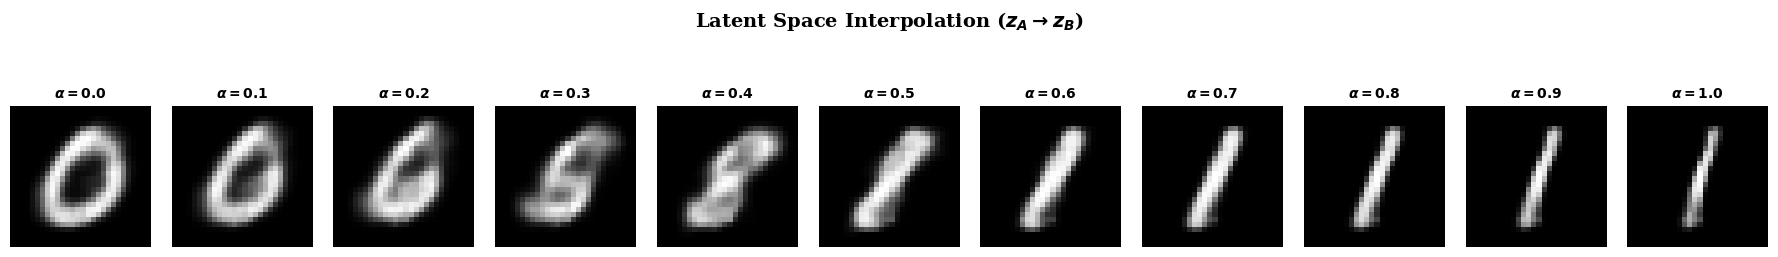

In [ ]:
# 1. Obtain latent representations for the test set
z_means, _, _ = vae.encoder.predict(X_test_conv)

# Select two distinct digits (e.g., first image of digit 0 and first image of digit 1)
index_A = np.where(y_test[:2000] == 0)[0][0]
index_B = np.where(y_test[:2000] == 1)[0][0]

z_A = z_means[index_A]
z_B = z_means[index_B]

# 2. Linear Interpolation: z(alpha) = (1 - alpha) * z_A + alpha * z_B
alphas = np.linspace(0.0, 1.0, 11)  # alpha = 0.0, 0.1, 0.2, ..., 1.0
interpolated_z = np.array([(1 - a) * z_A + a * z_B for a in alphas])

# 3. Decode every interpolated latent vector
decoded_interpolations = vae.decoder.predict(interpolated_z)

# 4. Plot 8: Latent Space Interpolation Sequence
fig, axes = plt.subplots(1, len(alphas), figsize=(18, 2.5))

for i, alpha in enumerate(alphas):
    axes[i].imshow(decoded_interpolations[i].reshape(28, 28), cmap="gray")
    axes[i].set_title(f"$\\alpha={alpha:.1f}$", fontsize=10)
    axes[i].axis("off")

plt.suptitle("Latent Space Interpolation ($z_A \\rightarrow z_B$)", fontsize=14, fontweight="bold", y=1.08)
plt.tight_layout()

# 5. Save plot to disk as PNG and EPS at 600 DPI
plt.savefig("latent_space_interpolation.png", dpi=600, bbox_inches="tight")
plt.savefig("latent_space_interpolation.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

In [ ]:
import pandas as pd

# 1. Evaluate VAE model loss metrics on test set
eval_results = vae.evaluate(X_test_conv, batch_size=128, return_dict=True)

recon_loss = eval_results["reconstruction_loss"]
kl_loss = eval_results["kl_loss"]
total_loss = eval_results["loss"]

# 2. Get predictions (reconstructed images) from VAE for image quality metrics
z_mean, z_log_var, z = vae.encoder.predict(X_test_conv)
vae_reconstructions = vae.decoder.predict(z_mean)

# 3. Reshape images to 2D for metric evaluations
orig_test_imgs = np.squeeze(X_test_conv, axis=-1)
recon_test_imgs = np.squeeze(vae_reconstructions, axis=-1)

# 4. Compute Test MSE, Test MAE, and Mean SSIM
test_mse = np.mean((orig_test_imgs - recon_test_imgs) ** 2)
test_mae = np.mean(np.abs(orig_test_imgs - recon_test_imgs))

ssim_scores = [
    ssim(orig, recon, data_range=1.0)
    for orig, recon in zip(orig_test_imgs, recon_test_imgs)
]
mean_ssim = np.mean(ssim_scores)

# 5. Format and display results table
vae_metrics_df = pd.DataFrame(
    [
        {"VAE Metric": "Reconstruction Loss", "Value": f"{recon_loss:.6f}"},
        {"VAE Metric": "KL Loss", "Value": f"{kl_loss:.6f}"},
        {"VAE Metric": "Total Loss", "Value": f"{total_loss:.6f}"},
        {"VAE Metric": "Test MSE", "Value": f"{test_mse:.6f}"},
        {"VAE Metric": "Test MAE", "Value": f"{test_mae:.6f}"},
        {"VAE Metric": "Mean SSIM", "Value": f"{mean_ssim:.6f}"},
    ]
)

print("VAE Test Set Evaluation Metrics")
print(vae_metrics_df.to_string(index=False))

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - kl_loss: 5.5630 - loss: 155.5825 - reconstruction_loss: 150.0196
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
VAE Test Set Evaluation Metrics
         VAE Metric      Value
Reconstruction Loss 150.019608
            KL Loss   5.562951
         Total Loss 155.582535
           Test MSE   0.043855
           Test MAE   0.102490
          Mean SSIM   0.485874


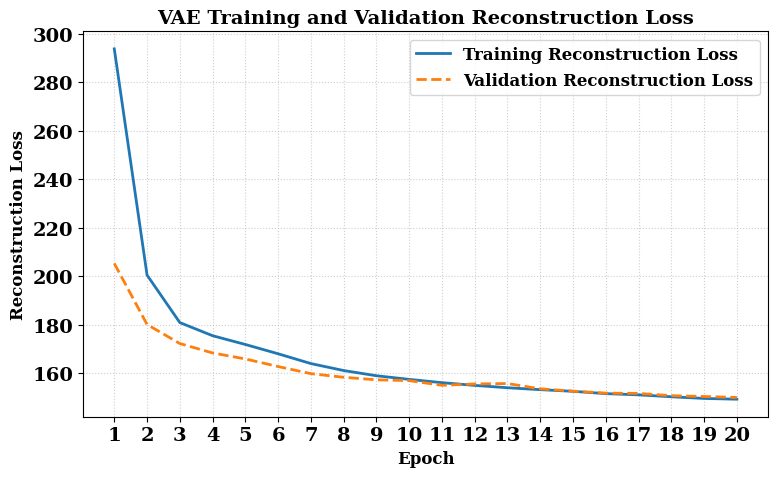

In [ ]:
train_recon_loss = vae_history.history["reconstruction_loss"]
val_recon_loss = vae_history.history.get("val_reconstruction_loss", None)
epochs = range(1, len(train_recon_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_recon_loss, label="Training Reconstruction Loss", color="#1f77b4", linewidth=2)

if val_recon_loss is not None:
    plt.plot(epochs, val_recon_loss, label="Validation Reconstruction Loss", color="#ff7f0e", linewidth=2, linestyle="--")

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Reconstruction Loss", fontsize=12)
plt.title("VAE Training and Validation Reconstruction Loss", fontsize=14, fontweight="bold")
plt.xticks(epochs)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()

# Save Plot 9 to disk as PNG and EPS at 600 DPI
plt.savefig("vae_reconstruction_loss_curve.png", dpi=600, bbox_inches="tight")
plt.savefig("vae_reconstruction_loss_curve.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


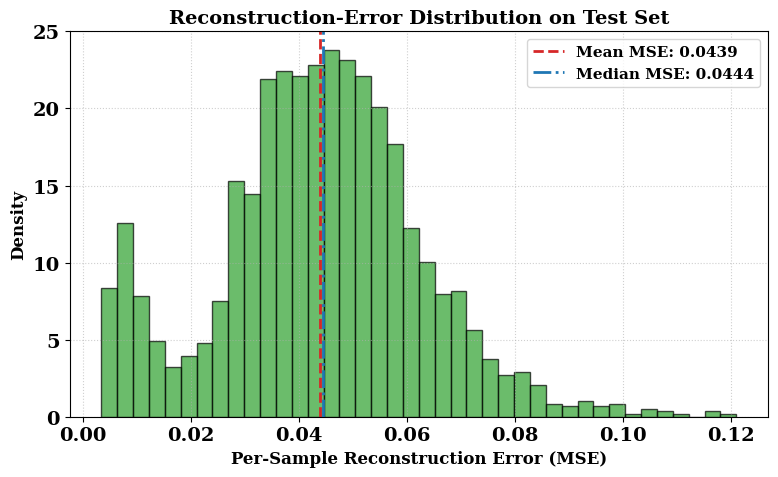

In [ ]:
z_mean, _, _ = vae.encoder.predict(X_test_conv)
vae_reconstructions = vae.decoder.predict(z_mean)

orig_test_imgs = np.squeeze(X_test_conv, axis=-1)
recon_test_imgs = np.squeeze(vae_reconstructions, axis=-1)

# 2. Calculate per-sample MSE across test set (2000 images)
per_sample_mse = np.mean((orig_test_imgs - recon_test_imgs) ** 2, axis=(1, 2))

# 3. Create Histogram and Density Distribution Plot
plt.figure(figsize=(8, 5))
n, bins, patches = plt.hist(
    per_sample_mse,
    bins=40,
    color="#2ca02c",
    edgecolor="black",
    alpha=0.7,
    density=True
)

# Reference indicators for mean and median reconstruction errors
mean_mse = np.mean(per_sample_mse)
median_mse = np.median(per_sample_mse)

plt.axvline(mean_mse, color="#d62728", linestyle="--", linewidth=2, label=f"Mean MSE: {mean_mse:.4f}")
plt.axvline(median_mse, color="#1f77b4", linestyle="-.", linewidth=2, label=f"Median MSE: {median_mse:.4f}")

plt.xlabel("Per-Sample Reconstruction Error (MSE)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title("Reconstruction-Error Distribution on Test Set", fontsize=14, fontweight="bold")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()

# Save Plot 10 to disk as PNG and EPS at 600 DPI
plt.savefig("reconstruction_error_distribution.png", dpi=600, bbox_inches="tight")
plt.savefig("reconstruction_error_distribution.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()

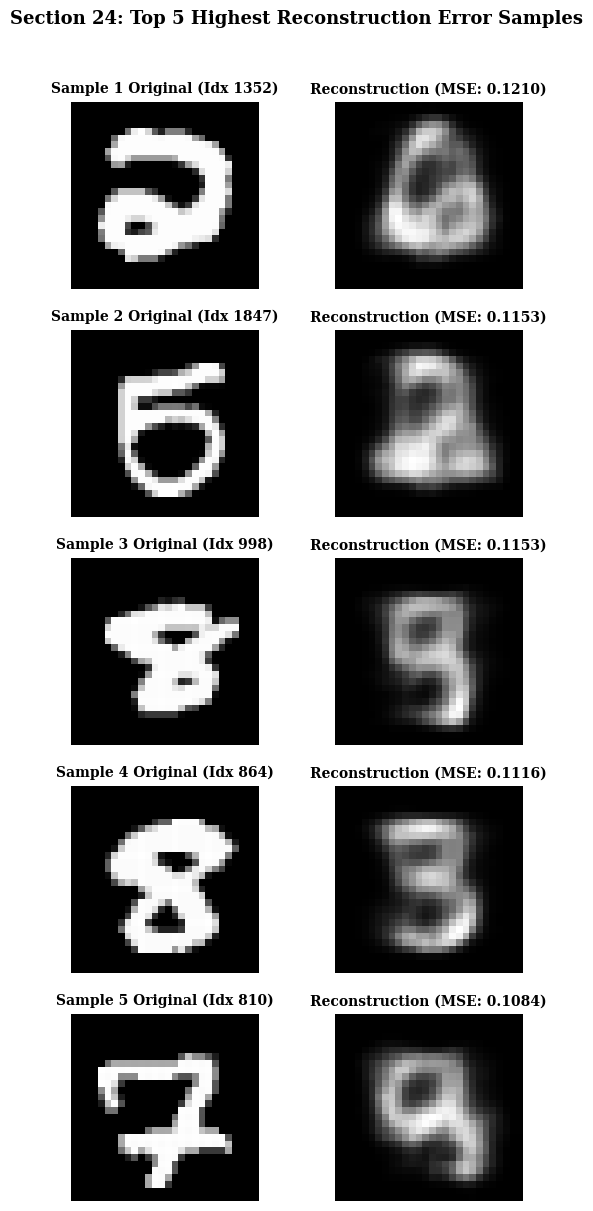

In [ ]:
# 1. Calculate per-sample reconstruction error (MSE) on the test set using VAE
z_mean_test, _, _ = vae.encoder.predict(X_test_conv, verbose=0)
vae_reconstructions = np.squeeze(vae.decoder.predict(z_mean_test, verbose=0), axis=-1)
orig_test_imgs = np.squeeze(X_test_conv, axis=-1)

per_sample_mse = np.mean((orig_test_imgs - vae_reconstructions) ** 2, axis=(1, 2))

# 2. Extract indices of the 5 images with the highest reconstruction error
top5_indices = np.argsort(per_sample_mse)[-5:][::-1]

# 3. Plot Top 5 Worst Reconstructions (Sample Original vs Reconstruction)
fig, axes = plt.subplots(5, 2, figsize=(6, 12))

for row_idx, img_idx in enumerate(top5_indices):
    # Original Image
    axes[row_idx, 0].imshow(orig_test_imgs[img_idx], cmap="gray")
    axes[row_idx, 0].set_title(f"Sample {row_idx + 1} Original (Idx {img_idx})", fontsize=10, fontweight="bold")
    axes[row_idx, 0].axis("off")

    # Reconstructed Image
    axes[row_idx, 1].imshow(vae_reconstructions[img_idx], cmap="gray")
    axes[row_idx, 1].set_title(f"Reconstruction (MSE: {per_sample_mse[img_idx]:.4f})", fontsize=10, fontweight="bold")
    axes[row_idx, 1].axis("off")

plt.suptitle("Section 24: Top 5 Highest Reconstruction Error Samples", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()

# Save plot as PNG and EPS at 600 DPI
plt.savefig("top5_high_error_samples.png", dpi=600, bbox_inches="tight")
plt.savefig("top5_high_error_samples.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

In [ ]:
import time

# Define dictionary of trained models and their respective test inputs/clean targets
models_to_evaluate = {
    "FC Autoencoder": (autoencoder, X_test_flat, X_test_flat.reshape(-1, 28, 28)),
    "Conv. Autoencoder": (conv_autoencoder, X_test_conv, np.squeeze(X_test_conv, axis=-1)),
    "Denoising CAE": (cdae_gaussian, X_test_conv_noisy_gauss, np.squeeze(X_test_conv, axis=-1)),
    "VAE": (vae, X_test_conv, np.squeeze(X_test_conv, axis=-1))
}

consolidated_results = []

for model_name, (model_obj, test_in, clean_target) in models_to_evaluate.items():
    # Measure inference execution time
    start_time = time.time()

    if model_name == "VAE":
        z_m, _, _ = model_obj.encoder.predict(test_in, verbose=0)
        reconstructions = np.squeeze(model_obj.decoder.predict(z_m, verbose=0), axis=-1)
        param_count = model_obj.encoder.count_params() + model_obj.decoder.count_params()
    else:
        preds = model_obj.predict(test_in, verbose=0)
        reconstructions = preds.reshape(-1, 28, 28)
        param_count = model_obj.count_params()

    execution_time = time.time() - start_time

    # Calculate metrics
    mse_val = np.mean((clean_target - reconstructions) ** 2)
    mae_val = np.mean(np.abs(clean_target - reconstructions))
    ssim_val = np.mean([
        ssim(orig, recon, data_range=1.0)
        for orig, recon in zip(clean_target, reconstructions)
    ])

    consolidated_results.append({
        "Model": model_name,
        "MSE": f"{mse_val:.6f}",
        "MAE": f"{mae_val:.6f}",
        "SSIM": f"{ssim_val:.6f}",
        "Parameters": f"{param_count:,}",
        "Inference Time (s)": f"{execution_time:.4f}"
    })

# Render Consolidated Table
df_consolidated = pd.DataFrame(consolidated_results)
print("Section 25: Consolidated Experimental Performance Table")
print(df_consolidated.to_string(index=False))

Section 25: Consolidated Experimental Performance Table
            Model      MSE      MAE     SSIM Parameters Inference Time (s)
   FC Autoencoder 0.020998 0.055382 0.751880    211,040             0.2192
Conv. Autoencoder 0.002506 0.014868 0.974898     74,497             0.2186
    Denoising CAE 0.004799 0.021508 0.943831     74,497             0.2205
              VAE 0.043855 0.102490 0.485874    284,933             0.4418


In [ ]:
# 1. Define latent dimensions to evaluate
latent_dims = [2, 8, 16, 32]
study_results = []
mse_values = []
ssim_values = []

orig_test_imgs = X_test_flat.reshape(-1, 28, 28)

# 2. Iterate through each latent dimension, build, train, and evaluate
for d_z in latent_dims:
    if d_z == 16:
        # Reuse the already-trained main autoencoder (same architecture) so this row matches Section 9
        ae_model = autoencoder
    else:
        # Architecture: 784 -> 128 -> 32 -> d_z -> 32 -> 128 -> 784
        input_img = layers.Input(shape=(784,))
        encoded = layers.Dense(128, activation="relu")(input_img)
        encoded = layers.Dense(32, activation="relu")(encoded)
        latent = layers.Dense(d_z, activation="relu", name=f"latent_space_{d_z}")(encoded)

        decoded = layers.Dense(32, activation="relu")(latent)
        decoded = layers.Dense(128, activation="relu")(decoded)
        decoded_output = layers.Dense(784, activation="sigmoid")(decoded)

        ae_model = keras.Model(inputs=input_img, outputs=decoded_output, name=f"ae_dz_{d_z}")

        ae_model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-3),
            loss="binary_crossentropy"
        )

        # Train the model
        ae_model.fit(
            X_train_flat,
            X_train_flat,
            epochs=20,
            batch_size=128,
            shuffle=True,
            validation_data=(X_test_flat, X_test_flat),
            verbose=0
        )

    # Reconstruct test set
    test_preds = ae_model.predict(X_test_flat, verbose=0)
    recon_test_imgs = test_preds.reshape(-1, 28, 28)

    # Compute MSE and SSIM
    mse_val = np.mean((orig_test_imgs - recon_test_imgs) ** 2)
    ssim_val = np.mean([
        ssim(orig, recon, data_range=1.0)
        for orig, recon in zip(orig_test_imgs, recon_test_imgs)
    ])
    param_count = ae_model.count_params()

    mse_values.append(mse_val)
    ssim_values.append(ssim_val)

    study_results.append({
        "Latent Dimension": d_z,
        "MSE": f"{mse_val:.6f}",
        "SSIM": f"{ssim_val:.6f}",
        "Parameters": param_count
    })

# 3. Report Table
df_study = pd.DataFrame(study_results)
print("Additional Latent-Dimension Study Results")
print(df_study.to_string(index=False))

Additional Latent-Dimension Study Results
 Latent Dimension      MSE     SSIM  Parameters
                2 0.047703 0.424548      210130
                8 0.029990 0.652452      210520
               16 0.020998 0.751880      211040
               32 0.021501 0.742331      212080


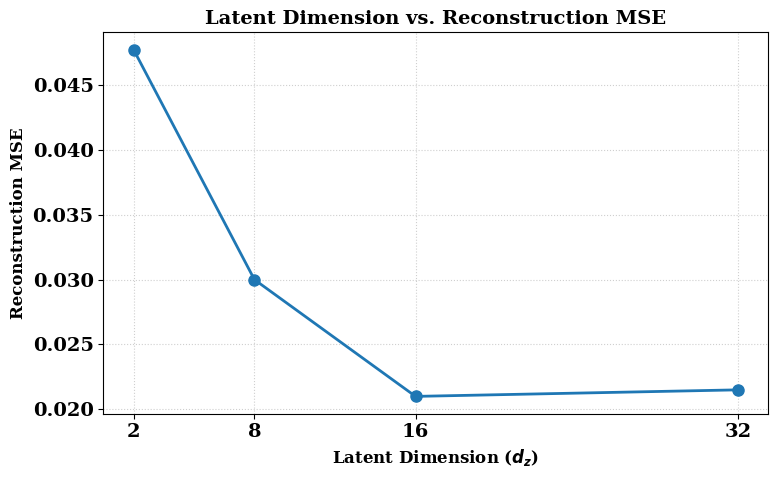

In [ ]:
# 4. Plot: Latent Dimension vs. Reconstruction MSE
plt.figure(figsize=(8, 5))
plt.plot(latent_dims, mse_values, marker="o", color="#1f77b4", linewidth=2, markersize=8)

plt.xlabel("Latent Dimension ($d_z$)", fontsize=12, fontweight="bold")
plt.ylabel("Reconstruction MSE", fontsize=12, fontweight="bold")
plt.title("Latent Dimension vs. Reconstruction MSE", fontsize=14, fontweight="bold")
plt.xticks(latent_dims)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

# Save plot to disk as PNG and EPS at 600 DPI
plt.savefig("latent_dimension_vs_mse.png", dpi=600, bbox_inches="tight")
plt.savefig("latent_dimension_vs_mse.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

# Additional Exercises

In [ ]:
cae_results = []
orig_imgs = np.squeeze(X_test_conv, axis=-1)
seeds = [0, 1, 2]

for d_z in [4, 8, 16, 32]:
    mse_runs, ssim_runs = [], []
    for seed in seeds:
        keras.utils.set_random_seed(seed)

        # Encoder
        inp = layers.Input(shape=(28, 28, 1))
        x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
        x = layers.MaxPooling2D(2, padding="same")(x)
        x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
        x = layers.MaxPooling2D(2, padding="same")(x)
        x = layers.Flatten()(x)
        latent = layers.Dense(d_z, activation="relu", name="latent")(x)

        # Decoder
        x = layers.Dense(7 * 7 * 64, activation="relu")(latent)
        x = layers.Reshape((7, 7, 64))(x)
        x = layers.UpSampling2D(2)(x)
        x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
        x = layers.UpSampling2D(2)(x)
        out = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

        cae_dz = keras.Model(inp, out)
        cae_dz.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
        cae_dz.fit(X_train_conv, X_train_conv, epochs=15, batch_size=128, shuffle=True, verbose=0)

        preds = np.squeeze(cae_dz.predict(X_test_conv, verbose=0), axis=-1)
        mse_runs.append(np.mean((orig_imgs - preds) ** 2))
        ssim_runs.append(np.mean([ssim(o, r, data_range=1.0) for o, r in zip(orig_imgs, preds)]))

    cae_results.append({
        "Latent Dim (dz)": d_z,
        "MSE": f"{np.mean(mse_runs):.6f}",
        "MSE std": f"{np.std(mse_runs):.6f}",
        "SSIM": f"{np.mean(ssim_runs):.6f}",
        "SSIM std": f"{np.std(ssim_runs):.6f}",
    })

print(f"Mean over {len(seeds)} random seeds")
print(pd.DataFrame(cae_results).to_string(index=False))

Mean over 3 random seeds
 Latent Dim (dz)      MSE  MSE std     SSIM SSIM std
               4 0.051764 0.011996 0.363029 0.185601
               8 0.032888 0.006689 0.632655 0.080468
              16 0.030656 0.017398 0.631611 0.226413
              32 0.016258 0.007167 0.815546 0.087055


In [ ]:
pred_gauss = np.squeeze(cdae_gaussian.predict(X_test_conv_noisy_gauss, verbose=0), axis=-1)
pred_sp = np.squeeze(cdae_sp.predict(X_test_conv_noisy_sp, verbose=0), axis=-1)

mse_g = np.mean((orig_imgs - pred_gauss) ** 2)
ssim_g = np.mean([ssim(o, r, data_range=1.0) for o, r in zip(orig_imgs, pred_gauss)])

mse_sp = np.mean((orig_imgs - pred_sp) ** 2)
ssim_sp = np.mean([ssim(o, r, data_range=1.0) for o, r in zip(orig_imgs, pred_sp)])

df_ex2 = pd.DataFrame([
    {"Noise Type": "Gaussian (sigma=0.2)", "MSE": f"{mse_g:.6f}", "SSIM": f"{ssim_g:.6f}"},
    {"Noise Type": "Salt-and-Pepper (p=0.10)", "MSE": f"{mse_sp:.6f}", "SSIM": f"{ssim_sp:.6f}"}
])
print(df_ex2.to_string(index=False))

              Noise Type      MSE     SSIM
    Gaussian (sigma=0.2) 0.004799 0.943831
Salt-and-Pepper (p=0.10) 0.004705 0.947354


In [ ]:
for s_val in [0.1, 0.3]:
    n_test = np.clip(X_test_conv + np.random.normal(0, s_val, X_test_conv.shape), 0.0, 1.0)
    pred_s = np.squeeze(cdae_gaussian.predict(n_test, verbose=0), axis=-1)
    ssim_s = np.mean([ssim(o, r, data_range=1.0) for o, r in zip(orig_imgs, pred_s)])
    print(f"Noise Level sigma = {s_val:.1f}  -->  Test SSIM: {ssim_s:.6f}")

Noise Level sigma = 0.1  -->  Test SSIM: 0.958709
Noise Level sigma = 0.3  -->  Test SSIM: 0.865989


In [ ]:
inp = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(inp) # (14, 14, 32)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)   # (7, 7, 64)

x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x) # (14, 14, 64)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x) # (28, 28, 32)
out_trans = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)  # (28, 28, 1)

cae_trans = keras.Model(inp, out_trans)
cae_trans.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
cae_trans.fit(X_train_conv, X_train_conv, epochs=20, batch_size=128, shuffle=True, verbose=0)

pred_trans = np.squeeze(cae_trans.predict(X_test_conv, verbose=0), axis=-1)
pred_upsample = np.squeeze(conv_autoencoder.predict(X_test_conv, verbose=0), axis=-1)

mse_trans = np.mean((orig_imgs - pred_trans) ** 2)
ssim_trans = np.mean([ssim(o, r, data_range=1.0) for o, r in zip(orig_imgs, pred_trans)])

mse_up = np.mean((orig_imgs - pred_upsample) ** 2)
ssim_up = np.mean([ssim(o, r, data_range=1.0) for o, r in zip(orig_imgs, pred_upsample)])

df_ex4 = pd.DataFrame([
    {"Decoder Type": "UpSampling2D", "MSE": f"{mse_up:.6f}", "SSIM": f"{ssim_up:.6f}"},
    {"Decoder Type": "Conv2DTranspose", "MSE": f"{mse_trans:.6f}", "SSIM": f"{ssim_trans:.6f}"}
])
print(df_ex4.to_string(index=False))

   Decoder Type      MSE     SSIM
   UpSampling2D 0.002506 0.974898
Conv2DTranspose 0.000593 0.993310


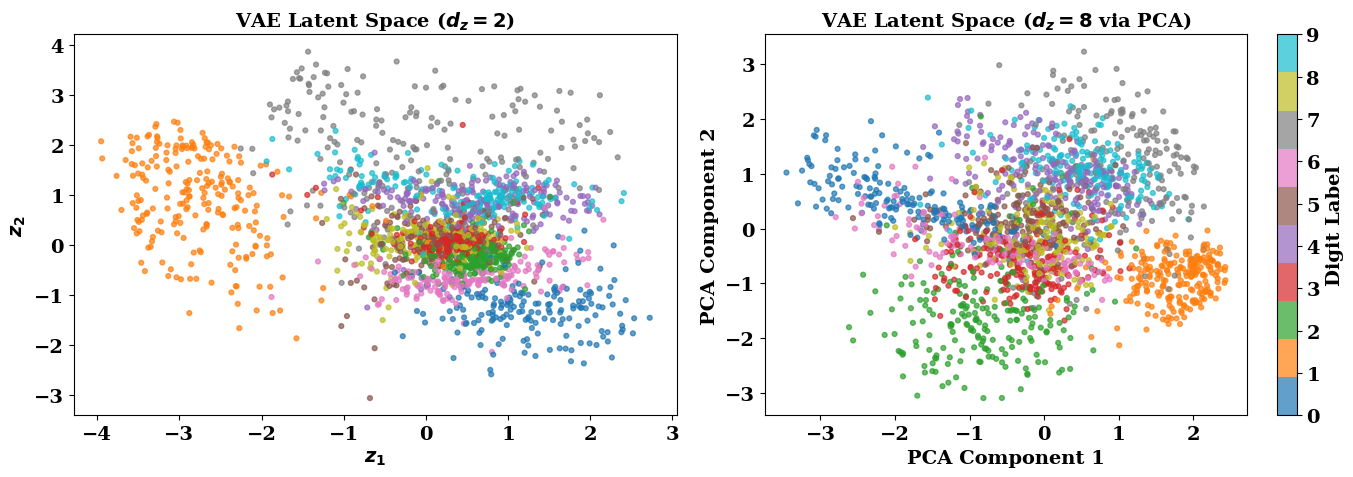

In [ ]:
from sklearn.decomposition import PCA

# 1. Train dz=8 VAE
enc_in_8 = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(enc_in_8)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean_8 = layers.Dense(8)(x)
z_log_var_8 = layers.Dense(8)(x)
z_8 = Sampling()([z_mean_8, z_log_var_8])
encoder_8 = keras.Model(enc_in_8, [z_mean_8, z_log_var_8, z_8])

dec_in_8 = layers.Input(shape=(8,))
x = layers.Dense(7 * 7 * 64, activation="relu")(dec_in_8)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
dec_out_8 = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder_8 = keras.Model(dec_in_8, dec_out_8)

vae_8 = VAE(encoder_8, decoder_8)
vae_8.compile(optimizer=keras.optimizers.Adam(1e-3))
vae_8.fit(X_train_conv, epochs=15, batch_size=128, shuffle=True, verbose=0)

# Extract latent vectors
zm_2, _, _ = vae.encoder.predict(X_test_conv, verbose=0)         # dz=2
zm_8, _, _ = vae_8.encoder.predict(X_test_conv, verbose=0)       # dz=8
zm_8_pca = PCA(n_components=2).fit_transform(zm_8)               # Project 8D -> 2D for plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc1 = axes[0].scatter(zm_2[:, 0], zm_2[:, 1], c=y_test[:2000], cmap="tab10", alpha=0.7, s=12)
axes[0].set_title("VAE Latent Space ($d_z = 2$)", fontweight="bold")
axes[0].set_xlabel("$z_1$"); axes[0].set_ylabel("$z_2$")

sc2 = axes[1].scatter(zm_8_pca[:, 0], zm_8_pca[:, 1], c=y_test[:2000], cmap="tab10", alpha=0.7, s=12)
axes[1].set_title("VAE Latent Space ($d_z = 8$ via PCA)", fontweight="bold")
axes[1].set_xlabel("PCA Component 1"); axes[1].set_ylabel("PCA Component 2")
plt.colorbar(sc2, ax=axes[1], label="Digit Label")
plt.tight_layout()
# Save plot to disk as PNG and EPS at 600 DPI
plt.savefig("vae_latent_space_dz2_vs_dz8.png", dpi=600, bbox_inches="tight")
plt.savefig("vae_latent_space_dz2_vs_dz8.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

In [ ]:
class BetaVAE(VAE):
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super().__init__(encoder, decoder, **kwargs)
        self.beta = beta

    def train_step(self, data):
        if isinstance(data, tuple): data = data[0]
        with tf.GradientTape() as tape:
            z_m, z_lv, z = self.encoder(data)
            recon = self.decoder(z)
            recon_loss = tf.reduce_mean(tf.reduce_sum(keras.losses.binary_crossentropy(data, recon), axis=(1, 2)))
            kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + z_lv - tf.square(z_m) - tf.exp(z_lv), axis=1))
            total_loss = recon_loss + self.beta * kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(), "reconstruction_loss": self.reconstruction_loss_tracker.result(), "kl_loss": self.kl_loss_tracker.result()}

# Train Beta=5 VAE with its OWN freshly initialised encoder/decoder (same architecture as the standard VAE)
enc_in_b = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(enc_in_b)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation="relu")(x)
z_mean_b = layers.Dense(latent_dim)(x)
z_log_var_b = layers.Dense(latent_dim)(x)
z_b = Sampling()([z_mean_b, z_log_var_b])
encoder_b = keras.Model(enc_in_b, [z_mean_b, z_log_var_b, z_b])

dec_in_b = layers.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation="relu")(dec_in_b)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
dec_out_b = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder_b = keras.Model(dec_in_b, dec_out_b)

beta_vae = BetaVAE(encoder_b, decoder_b, beta=5.0)
beta_vae.compile(optimizer=keras.optimizers.Adam(1e-3))
b_hist = beta_vae.fit(X_train_conv, epochs=20, batch_size=128, shuffle=True, verbose=0)

res_beta1 = vae.evaluate(X_test_conv, batch_size=128, return_dict=True, verbose=0)
res_beta5 = beta_vae.evaluate(X_test_conv, batch_size=128, return_dict=True, verbose=0)

df_ex6 = pd.DataFrame([
    {"Beta Weight": "1.0 (Standard)", "Reconstruction Loss": f"{res_beta1['reconstruction_loss']:.4f}", "KL Loss": f"{res_beta1['kl_loss']:.4f}"},
    {"Beta Weight": "5.0 (Beta-VAE)", "Reconstruction Loss": f"{res_beta5['reconstruction_loss']:.4f}", "KL Loss": f"{res_beta5['kl_loss']:.4f}"}
])
print(df_ex6.to_string(index=False))

   Beta Weight Reconstruction Loss KL Loss
1.0 (Standard)            150.1318  5.5630
5.0 (Beta-VAE)            155.5809  3.4613


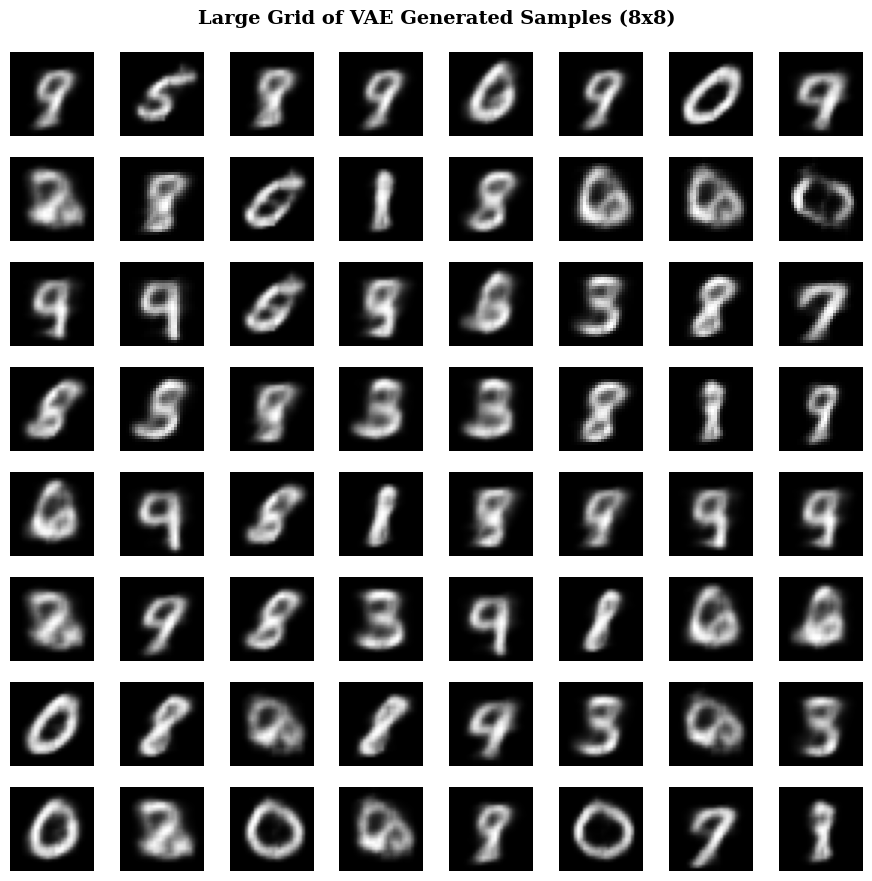

In [ ]:
grid_size = 8
z_grid_samples = np.random.normal(loc=0.0, scale=1.0, size=(grid_size * grid_size, latent_dim))
gen_grid_imgs = vae.decoder.predict(z_grid_samples, verbose=0)

fig, axes = plt.subplots(grid_size, grid_size, figsize=(9, 9))
for i, ax in enumerate(axes.flat):
    ax.imshow(gen_grid_imgs[i].reshape(28, 28), cmap="gray")
    ax.axis("off")
plt.suptitle(f"Large Grid of VAE Generated Samples ({grid_size}x{grid_size})", fontsize=14, fontweight="bold")
plt.tight_layout()
# Save plot to disk as PNG and EPS at 600 DPI
plt.savefig("vae_generated_grid_8x8.png", dpi=600, bbox_inches="tight")
plt.savefig("vae_generated_grid_8x8.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()

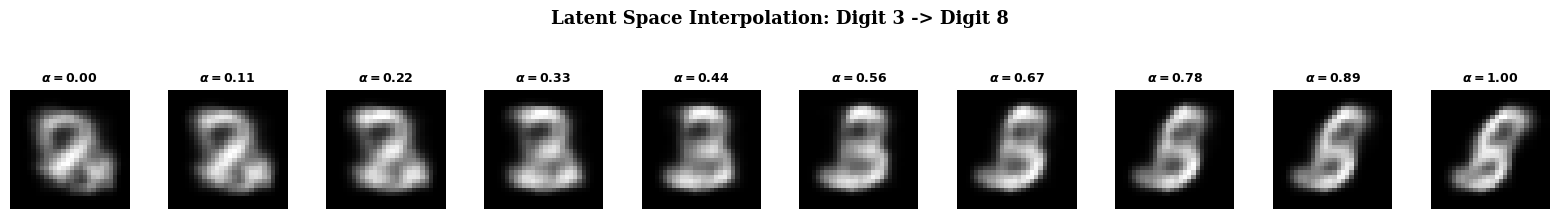

In [ ]:
zm_test, _, _ = vae.encoder.predict(X_test_conv, verbose=0)

idx_3 = np.where(y_test[:2000] == 3)[0][0]
idx_8 = np.where(y_test[:2000] == 8)[0][0]

z_3 = zm_test[idx_3]
z_8 = zm_test[idx_8]

alphas = np.linspace(0.0, 1.0, 10)
z_interp = np.array([(1 - a) * z_3 + a * z_8 for a in alphas])
decoded_interp = vae.decoder.predict(z_interp, verbose=0)

fig, axes = plt.subplots(1, len(alphas), figsize=(16, 2))
for i, a in enumerate(alphas):
    axes[i].imshow(decoded_interp[i].reshape(28, 28), cmap="gray")
    axes[i].set_title(f"$\\alpha={a:.2f}$", fontsize=9)
    axes[i].axis("off")
plt.suptitle("Latent Space Interpolation: Digit 3 -> Digit 8", fontsize=13, fontweight="bold", y=1.1)
plt.tight_layout()
# Save plot to disk as PNG and EPS at 600 DPI
plt.savefig("latent_space_interpolation_3_to_8.png", dpi=600, bbox_inches="tight")
plt.savefig("latent_space_interpolation_3_to_8.eps", format="eps", dpi=600, bbox_inches="tight")

plt.show()